## Conditional Workflows in LangGraph

### 1. Simple Math Workflow for Quadratic Equation
```mermaid
flowchart TD
    START([__start__]):::terminal --> show_equation:::node
    show_equation --> calculate_discriminant:::node
    calculate_discriminant:::node -.-> no_real_roots:::node
    calculate_discriminant -. d > 0 .-> real_roots:::node
    calculate_discriminant -.-> repeated_roots:::node
    no_real_roots --> END([__end__]):::terminal
    real_roots --> END
    repeated_roots --> END

    classDef terminal fill:#4a90d9,stroke:#2c5f8a,color:#fff,rx:20,ry:20
    classDef node fill:#b0a8e0,stroke:#7b6fbf,color:#1a1a1a
```

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal


In [3]:
# state
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [4]:
def show_equation(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {
        'equation': equation
    }

def calculate_discriminant(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {
        'discriminant': discriminant
    }

def real_roots(state: QuadState):

    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])

    result = f"Two distinct real roots: {root1} and {root2}"

    return {
        'result': result 
    }

def repeated_roots(state: QuadState):

    root = -state['b'] / (2*state['a'])
    result = f"One repeated real root: {root}"
    return {
        'result': result
    }

def complex_roots(state: QuadState):

    real_part = -state['b'] / (2*state['a'])
    imaginary_part = (abs(state['discriminant'])**0.5) / (2*state['a'])
    root1 = f"{real_part} + {imaginary_part}i"
    root2 = f"{real_part} - {imaginary_part}i"

    result = f"Two complex roots: {root1} and {root2}"
    return {
        'result': result 
    }

In [6]:
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_roots', 'complex_roots']:

    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'complex_roots'

In [7]:
graph = StateGraph(QuadState)

graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('complex_roots', complex_roots)


graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('complex_roots', END)

compiled_graph = graph.compile()

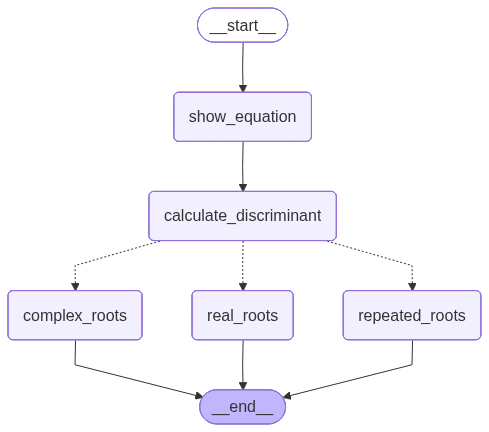

In [9]:
compiled_graph

In [10]:
initial_state = {
    'a': 1, 
    'b': -3,
    'c': 2
}
final_state = compiled_graph.invoke(initial_state)

In [11]:
final_state['result']

'Two distinct real roots: 2.0 and 1.0'

### 2. LLM based review handling workflow  
```mermaid
flowchart TD
    START([__start__]):::terminal --> find_sentiment:::node
    find_sentiment -. -ve .-> run_diagnosis:::node
    find_sentiment -. +ve .-> positive_response:::node
    run_diagnosis --> negative_response:::node
    negative_response --> END([__end__]):::terminal
    positive_response --> END

    classDef terminal fill:#4a90d9,stroke:#2c5f8a,color:#fff
    classDef node fill:#b0a8e0,stroke:#7b6fbf,color:#1a1a1a
```

In [ ]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import PromptTemplate
from IPython.display import Image, Markdown, display
from pydantic import BaseModel, Field
from typing import Literal
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [14]:
load_dotenv()

True

In [35]:
llm = ChatOpenAI(model='gpt-4o', temperature=0)

In [36]:
class SentimentSchema(BaseModel):

    sentiment: Literal['positive', 'negative'] = Field(description="The sentiment of the review, either 'positive' or 'negative'")


class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
    

In [37]:
structured_llm = llm.with_structured_output(SentimentSchema)

In [38]:
structured_llm2 = llm.with_structured_output(DiagnosisSchema)

In [39]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [40]:
def find_sentiment(state: ReviewState):
    prompt = PromptTemplate(
        template = "Determine if the following review is positive or negative: {review}",
        input_variables=['review']
    )
    sentiment = structured_llm.invoke(prompt.format(review=state['review']))
    return {'sentiment': sentiment.sentiment}


def positive_response(state: ReviewState):

    prompt = PromptTemplate(
        template = """Write a warm thank-you message in response to this review:\n\n\"{review}\"\n Also, kindly ask the user to leave feedback on our website.""",
        input_variables=['review']
    )

    response = llm.invoke(prompt.format(review=state['review']))

    return {'response': response.content}


def run_diagnosis(state: ReviewState):

    prompt = PromptTemplate(
        template = """Diagnose this negative review:\n\n{review}\n
    Return issue_type, tone, and urgency.
    """,
        input_variables=['review']
    )
    response = structured_llm2.invoke(prompt.format(review=state['review']))
    return {'diagnosis': response.model_dump()}


def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']
    issue_type = diagnosis['issue_type']
    tone = diagnosis['tone']
    urgency = diagnosis['urgency']

    prompt = PromptTemplate(
        template = """You are a support assistant.
The user had a '{issue_type}' issue, sounded '{tone}', and marked urgency as '{urgency}'.
Write an empathetic, helpful resolution message.
""",
        input_variables=['issue_type', 'tone', 'urgency']
    )

    formatted_prompt = prompt.format(issue_type=issue_type, tone=tone, urgency=urgency)

    response = llm.invoke(formatted_prompt)
    return {'response': response.content}

In [41]:
def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [42]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

compiled_graph = graph.compile()

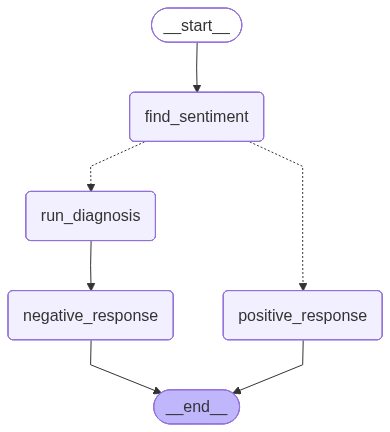

In [32]:
compiled_graph

In [43]:
intial_state={
    'review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

In [44]:
final_state = compiled_graph.invoke(intial_state)

In [46]:
final_state

{'review': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "I'm really sorry to hear that you're experiencing this issue, and I completely understand how frustrating it can be, especially when it's urgent. Let's work together to resolve this as quickly as possible. Could you please provide me with a few more details about the bug you're encountering? Any specific error messages or steps leading up to the issue would be incredibly helpful. Rest assured, I'm here to assist you every step of the way until we get this sorted out. Thank you for your patience and understanding."}

In [47]:
display(Markdown(final_state['response']))

I'm really sorry to hear that you're experiencing this issue, and I completely understand how frustrating it can be, especially when it's urgent. Let's work together to resolve this as quickly as possible. Could you please provide me with a few more details about the bug you're encountering? Any specific error messages or steps leading up to the issue would be incredibly helpful. Rest assured, I'm here to assist you every step of the way until we get this sorted out. Thank you for your patience and understanding.